In [2]:
import geopandas as gpd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import geopandas as gpd
import pandas as pd

# Load country boundaries
world = gpd.read_file('/mnt/warehouse/shifting_cultivation/111_result/HDI_analysis/hdi_new_with_sc.gpkg')

# Load SC distances
sc_pl = gpd.read_file("/mnt/warehouse/shifting_cultivation/111_result/density/projected/distance_pl_ag_hub.gpkg")

In [4]:
sc_pl.columns

Index(['orig_value', 'ref_row', 'ref_col', 'edge_flag', 'inside_mask',
       'HubName', 'HubDist', 'distance_pl_hub_orig_value',
       'distance_pl_hub_ref_row', 'distance_pl_hub_ref_col',
       'distance_pl_hub_edge_flag', 'distance_pl_hub_inside_mask',
       'distance_pl_hub_HubName', 'distance_pl_hub_HubDist', 'geometry'],
      dtype='object')

In [5]:
sc_pl["plantation_distance_km"] = sc_pl["distance_pl_hub_HubDist"] / 1000
sc_pl["cropland_distance_km"] = sc_pl["HubDist"] / 1000

# Ensure CRS matches
world = world.to_crs(sc_pl.crs)

# Dissolve by continent
countries_continent = world.dissolve(by="continent", as_index=False)

# Spatial join: assign SC points to continent
sc_pl = gpd.sjoin(sc_pl, countries_continent[["continent", "geometry"]], how="left", predicate="within")

# Calculate global (all SC) statistics
global_stats = sc_pl[["plantation_distance_km", "cropland_distance_km"]].describe()
print("Global statistics:\n", global_stats)

# Calculate statistics by continent
continent_stats = sc_pl.groupby("continent")[["plantation_distance_km", "cropland_distance_km"]].describe()
print("\nContinent-level statistics:\n", continent_stats)

# # Optional: % SC cells within 5 km of Plantation/Cropland by continent
# threshold = 5
# pct_within = (
#     sc_pl.groupby("continent")[["plantation_distance_km","cropland_distance_km"]]
#     .apply(lambda df: (df <= threshold).sum() / len(df) * 100)
# )
# print("\n% of SC cells within 5 km by continent:\n", pct_within)

Global statistics:
        plantation_distance_km  cropland_distance_km
count            1.796771e+06          1.796771e+06
mean             3.670284e+00          7.826550e+00
std              5.830588e+00          1.257137e+01
min              4.904725e-01          4.904725e-01
25%              1.104735e+00          1.542073e+00
50%              1.557955e+00          3.424671e+00
75%              3.505766e+00          8.378695e+00
max              2.626664e+02          2.061475e+02

Continent-level statistics:
              plantation_distance_km                                          \
                              count      mean       std       min       25%   
continent                                                                     
Africa                     948434.0  5.215245  7.205544  0.493291  1.114208   
America                    412344.0  2.305428  3.837406  0.490472  1.098312   
Asia/Pacific               434825.0  1.591839  1.365744  0.491088  1.054714   
Europe  

In [7]:
sc_pl_simplified = sc_pl[sc_pl['edge_flag'] == 0]

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# copy to avoid modifying original
df = sc_pl_simplified.copy()

# merge Europe into America
df["continent_group"] = df["continent"].replace({
    "Europe": "America", "Asia/Pacific": "Asia-Oceania"
})

# check groups
print(df["continent_group"].unique())

['Africa' 'America' 'Asia-Oceania' nan]


In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = df.melt(
    id_vars=["continent_group"],
    value_vars=["plantation_distance_km", "cropland_distance_km"],
    var_name="landuse",
    value_name="distance_km"
)

plot_df["landuse"] = plot_df["landuse"].replace({
    "plantation_distance_km": "Plantation",
    "cropland_distance_km": "Cropland"
})

In [15]:
# Calculate statistics by continent
continent_summary = df.groupby("continent_group")[["plantation_distance_km", "cropland_distance_km"]].describe()
print("\nContinent-level statistics:\n", continent_summary)


Continent-level statistics:
                 plantation_distance_km                                \
                                 count      mean       std       min   
continent_group                                                        
Africa                        927308.0  5.217770  7.205631  0.493291   
America                       404495.0  2.316220  3.853675  0.490472   
Asia-Oceania                  425320.0  1.595885  1.367454  0.494168   

                                                           \
                      25%       50%       75%         max   
continent_group                                             
Africa           1.114212  2.480759  5.918974  159.730113   
America          1.098336  1.115972  2.211941  129.159604   
Asia-Oceania     1.055567  1.111383  1.565312  262.666395   

                cropland_distance_km                                           \
                               count      mean        std       min       25%   
continen

In [16]:
def proximity_stats(df, distance_col, thresholds=(2, 5, 10)):
    out = []
    for continent, g in df.groupby("continent_group"):
        for d in thresholds:
            pct = (g[distance_col] <= d).mean() * 100
            out.append({
                "continent": continent,
                "distance_type": distance_col,
                "threshold_km": d,
                "percent_within": pct
            })
    return pd.DataFrame(out)

      continent           distance_type  threshold_km  percent_within
0        Africa  plantation_distance_km             2       38.433940
1        Africa  plantation_distance_km             5       71.147235
2        Africa  plantation_distance_km            10       86.753376
3       America  plantation_distance_km             2       71.977404
4       America  plantation_distance_km             5       92.814992
5       America  plantation_distance_km            10       97.145329
6  Asia-Oceania  plantation_distance_km             2       79.504608
7  Asia-Oceania  plantation_distance_km             5       97.793426
8  Asia-Oceania  plantation_distance_km            10       99.591837
0        Africa    cropland_distance_km             2       37.059855
1        Africa    cropland_distance_km             5       67.168082
2        Africa    cropland_distance_km            10       80.705871
3       America    cropland_distance_km             2       30.579364
4       America    c

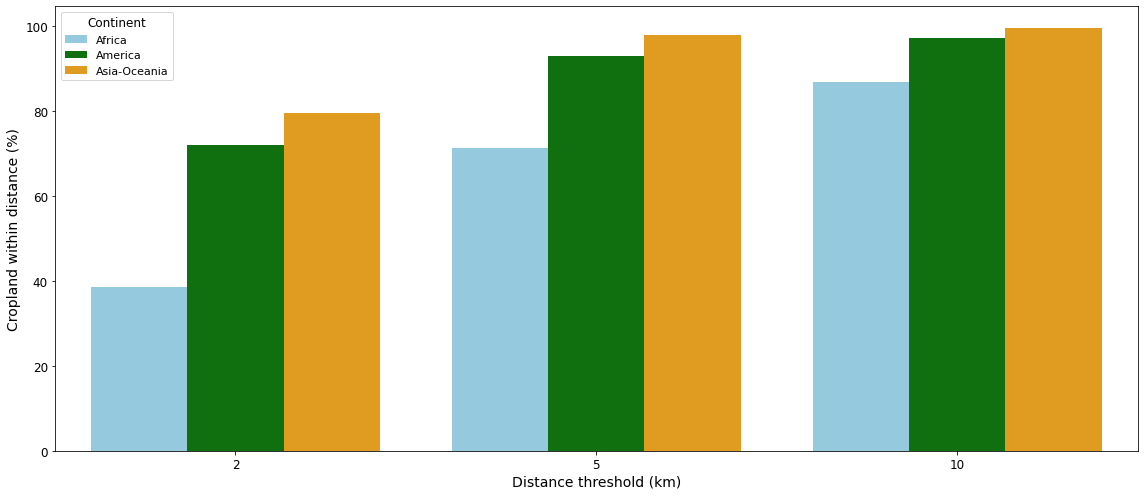

In [17]:
plantation_prox = proximity_stats(
    df,
    "plantation_distance_km"
)

cropland_prox = proximity_stats(
    df,
    "cropland_distance_km"
)

prox_stats = pd.concat([plantation_prox, cropland_prox])
print(prox_stats)

prox_table = prox_stats.pivot_table(
    index=["continent", "distance_type"],
    columns="threshold_km",
    values="percent_within"
)

prox_table = prox_table.round(1)
print(prox_table)

continent_colors = {
    "Africa": "skyblue",
    "America": "green",
    "Asia-Oceania": "orange"
}

plt.figure(figsize=(16,7))

ax = sns.barplot(
    data=plantation_prox,
    x="threshold_km",
    y="percent_within",
    hue="continent",
    palette=continent_colors
)

# Axis labels
ax.set_ylabel("Cropland within distance (%)", fontsize=14)
ax.set_xlabel("Distance threshold (km)", fontsize=14)

# Tick labels
ax.tick_params(axis="both", labelsize=12)

# Legend
plt.legend(title="Continent", title_fontsize=12, fontsize=11)

plt.tight_layout()
#plt.savefig('/mnt/warehouse/shifting_cultivation/111_result/figure/distance/plantation_distance.png')
plt.show()


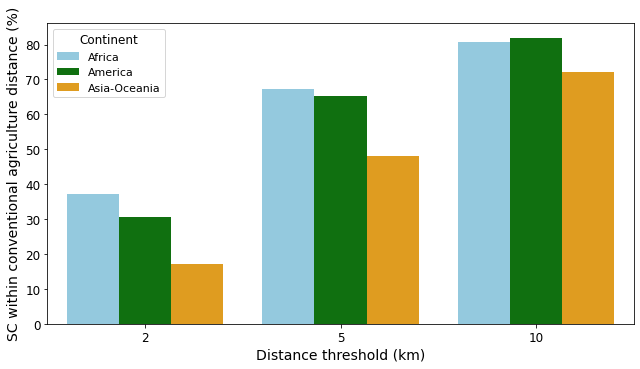

In [21]:
plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=cropland_prox,
    x="threshold_km",
    y="percent_within",
    hue="continent",
    palette=continent_colors
)

# Axis labels
ax.set_ylabel("SC within conventional agriculture distance (%)", fontsize=14)
ax.set_xlabel("Distance threshold (km)", fontsize=14)

# Tick labels
ax.tick_params(axis="both", labelsize=12)

# Legend
plt.legend(title="Continent", title_fontsize=12, fontsize=11)

plt.tight_layout()
#plt.savefig('/mnt/warehouse/shifting_cultivation/111_result/figure/distance/cropland_distance.png', dpi=600)
plt.show()
